In [3]:

import os
import sys

import networkx as nx

from pynauty import Graph as NautyGraph
from pynauty import autgrp

pynauty_available = True

import torch

import lightning.pytorch as pl

# import dataloader from torch_geometric
from torch.utils.data import DataLoader, Dataset

# import tensorboardlogger from pl
from lightning.pytorch.loggers import TensorBoardLogger

# wandb logger
# from lightning.pytorch.loggers import WandbLogger

# import the deepgraphgen modules that are just above
sys.path.append(os.path.dirname("/teamspace/studios/this_studio/graphgenerator/"))

from deepgraphgen.pl_trainer_g2pt_llada_pp_nasa import TrainerG2PT
from deepgraphgen.datageneration import generate_dataset

from deepgraphgen.datasets_spectre import (
    SpectreGraphDatasetV2,
    DatasetTree,
    DatasetSpectreIterableDataset,
)
from deepgraphgen.datasets_nasa_kg import NasaKGDataset
from scipy.stats import wasserstein_distance

import torch._dynamo

torch._dynamo.config.suppress_errors = True

In [27]:

EDGE_TO_NODE_RATIO = 7
NB_MAX_NODE = 64
NB_ROUND = 10

In [28]:


training_dataset = NasaKGDataset(
    path_nodes="/teamspace/studios/this_studio/graphgenerator/data_kg/nasa/nodes_nasa.parquet",
    path_edges="/teamspace/studios/this_studio/graphgenerator/data_kg/nasa/edges_nasa.parquet",
    nb_nodes_to_sample=NB_MAX_NODE,
    edges_to_nodes_ratio=EDGE_TO_NODE_RATIO,
)

iterdataset = DatasetSpectreIterableDataset(dataset=training_dataset)

Creating graph from edges and nodes


In [52]:

output_list = []
output_nodes_list = []
edge_label_list = []

for idx, data in enumerate(iterdataset):
    output = data["edges"].flatten()
    output_list.append(output)
    output_nodes_types = data["nodes_label"]
    output_nodes_list.append(output_nodes_types)
    edge_label_list.append(data["edges_label"])

    if idx > 32 * NB_ROUND:
        break

output_concat = torch.stack(output_list, dim=0)
output_node_concat = torch.stack(output_nodes_list, dim=0)
output_edge_concat = torch.stack(edge_label_list, dim=0)

tensor([[ 0,  0,  1,  ..., 10, 10, 10],
        [ 0,  0,  1,  ..., 10, 10, 10],
        [ 0,  0,  1,  ..., 10, 10, 10],
        ...,
        [ 0,  0,  0,  ...,  1,  6,  1],
        [ 0,  0,  0,  ...,  1,  6,  1],
        [ 0,  0,  0,  ...,  1,  1,  6]])

In [56]:

# now we create the graph for of the batch element
for batch_idx in range(output_concat.shape[0]):
    elements = set()

    U = output_concat[batch_idx, ::2].long().cpu().numpy()
    V = output_concat[batch_idx, 1::2].long().cpu().numpy()
    nodes_type = output_node_concat[batch_idx]
    edge_type = output_edge_concat[batch_idx]

    G = nx.MultiGraph()
    for i in range(U.shape[0]):
        if U[i] >= NB_MAX_NODE or V[i] >= NB_MAX_NODE:
            pass
        else:
            G.add_edge(U[i], V[i], labels=edge_type[i])

            # append U[i] and V[i] to the set            
            G.add_node(U[i], labels=nodes_type[U[i]])
            G.add_node(V[i], labels=nodes_type[V[i]])



    break

In [45]:
G.degree()

MultiDegreeView({0: 7, 21: 3, 22: 25, 52: 3, 25: 19, 54: 20, 55: 28, 7: 22, 1: 7, 2: 7, 3: 5, 59: 42, 63: 17, 4: 7, 35: 35, 51: 18, 5: 12, 45: 12, 27: 14, 36: 23, 47: 25, 16: 17, 49: 19, 6: 7, 26: 5, 23: 5, 60: 7, 14: 6, 29: 5, 31: 5, 28: 6, 41: 7, 42: 6, 19: 5, 62: 5, 17: 5, 48: 5, 40: 10, 44: 10, 8: 10, 53: 20, 38: 10, 18: 15, 9: 11, 10: 11, 11: 11, 12: 9, 13: 9, 15: 11, 61: 13, 50: 11, 30: 11, 34: 11, 46: 11, 43: 12, 32: 12, 39: 12, 56: 12, 58: 12, 33: 12, 24: 12, 20: 10, 57: 9, 37: 9})

In [46]:
degrees = dict(G.degree())
mean_degree = sum(degrees.values()) / NB_MAX_NODE
print(mean_degree)

12.0625


In [71]:
[cmap(G.edges[u, v][0]['labels']) for u, v in G.edges()]

ValueError: not enough values to unpack (expected 3, got 2)

/tmp/ipykernel_74541/3797003610.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', num_labels) # 'tab10' is good for up to 10 distinct categories


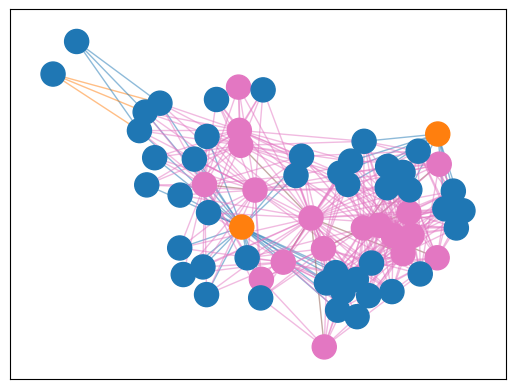

In [73]:
import matplotlib.pyplot as plt
num_labels = 10
cmap = plt.cm.get_cmap('tab10', num_labels) # 'tab10' is good for up to 10 distinct categories

# 3. Get the color for each node based on its 'labels' attribute
node_colors = [cmap(G.nodes[node]['labels']) for node in G.nodes()]
edge_colors = [cmap(G.edges[u, v, 0]['labels']) for u, v in G.edges()]

pos = nx.spring_layout(G, seed=42) # For consistent layout

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, alpha=0.5, width=1)


In [55]:
edge_label_list[0].shape

torch.Size([448])